In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/it_service_tickets.csv")

df = df.rename(columns={
    "Document": "ticket_text",
    "Topic_group": "category"
})

df = df.dropna(subset=["ticket_text", "category"])

df["ticket_text"] = df["ticket_text"].astype(str)
df["ticket_text"] = df["ticket_text"].str.lower()
df["ticket_text"] = df["ticket_text"].str.replace(r"\s+", " ", regex=True)
df["ticket_text"] = df["ticket_text"].str.strip()

df = df[df["ticket_text"].str.len() > 5]

df.to_csv("../data/processed/cleaned_tickets.csv", index=False)

In [2]:
print(df.shape)
print(df["category"].value_counts())
print(df["ticket_text"].str.len().describe())

(47837, 2)
category
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64
count    47837.000000
mean       291.873989
std        388.172619
min          7.000000
25%        110.000000
50%        175.000000
75%        304.000000
max       7015.000000
Name: ticket_text, dtype: float64


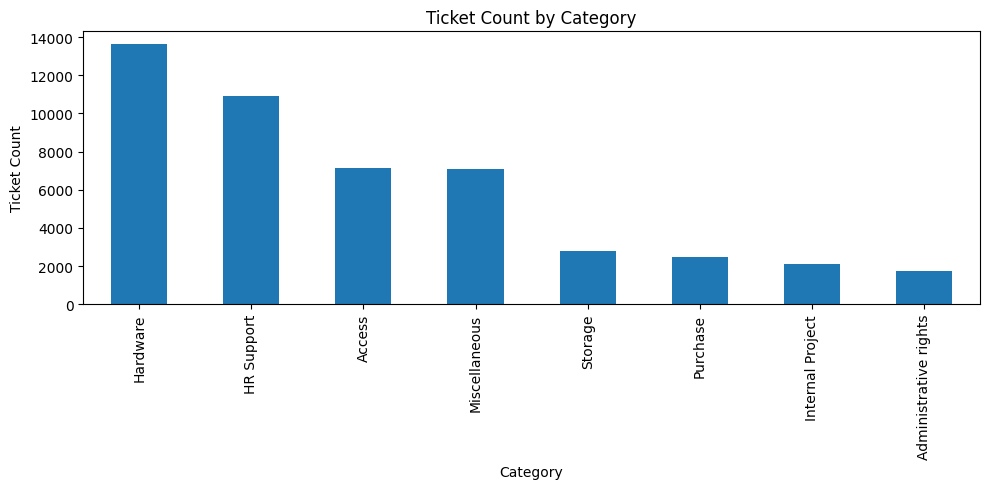

In [4]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar", figsize=(10, 5))
plt.title("Ticket Count by Category")
plt.xlabel("Category")
plt.ylabel("Ticket Count")
plt.tight_layout()
plt.show()

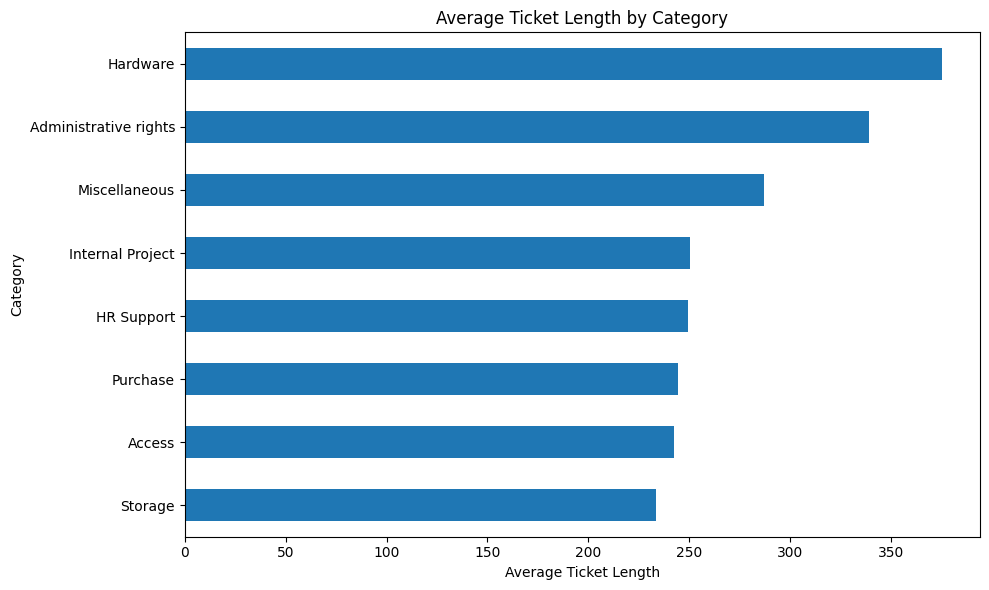

In [5]:
df["ticket_length"] = df["ticket_text"].str.len()

df.groupby("category")["ticket_length"].mean().sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average Ticket Length by Category")
plt.xlabel("Average Ticket Length")
plt.ylabel("Category")
plt.tight_layout()
plt.show()